In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import pandas as pd; pd.set_option("display.max_columns", None)
import sys;sys.path.append("..")
from config import Paths
from dataframes import *
from eals_data.utils import venn_diagram
from eals_radcliff.utils import dataframes as radcliff_dataframes
from eals_radcliff.utils import dataframes_paper as radcliff_dataframes_paper
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df_zx = load_zephyrx_data(
    at_least_efforts_fvc_usable=0,
    keep_usable_sessions_only=False,
    at_least_months_in_study=0,
    at_least_n_sessions=0,
    multiply_by_100=False,
)
print(f'N pALS: {df_zx.user_id.nunique()}, N sessions: {df_zx.session_id.nunique()}')

1 - ORIGINAL DIMENSIONS:                           subjects:     13, sessions:    123, spiro:    288, cols: 108
--- KEEP SESSIONS THAT MAY NOT MET USABILITY CRITERIA (eals_usability column)
--- WARNING computing 'total_timespan' for each user after usability criteria: False
--- TOTAL TIMESPAN: min 0, max 545, mean 309.21
--- NOT FILTERING SUBJECTS BY MINIMUM MONTHS IN STUDY
--- NOT FILTERING SUBJECTS BY MINIMUM NUMBER OF SESSIONS
N pALS: 13, N sessions: 123


In [10]:
df_zx.head(1)

,patientID,seriesID,spirometerID,coachedSessionID,bestEffortID,externalSessionID,created,timezoneName,deviceModel,appVersion,firmwareVersion,name,user_id,birth,genderAtBirth,ethnicity,heightInches,weightLbs,patientPosition,rejected,quality,originalQuality,acceptable,repeatable,notes,pftType,vc,vcPred,vcPercPred,vcLln,vcZ,vcLetterGrade,vcVariability,flowVolumeCurve,efforts,fvc,fvcPred,fvcPercPred,fvcLln,fvcZ,fvcLetterGrade,fvcVariability,fev1,fev1Pred,fev1PercPred,fev1Lln,fev1Z,fev1LetterGrade,fev1Variability,fev1Fvc,fev1FvcPred,fev1FvcPercPred,fev1FvcLln,fev1FvcZ,fev6,fivc,pef,bev,fet,pif,fef2575,fef2575Pred,fef2575PercPred,fef2575Lln,fef2575Z,bestEffortID_2019,acceptability_2019,fvcRepeatable_2019,fev1Repeatable_2019,flowVolumeCurve_2019,fvc_2019,fvcPred_2019,fvcPercPred_2019,fvcLln_2019,fvcZ_2019,fvcLetterGrade_2019,fvcVariability_2019,fev1_2019,fev1Pred_2019,fev1PercPred_2019,fev1Lln_2019,fev1Z_2019,fev1LetterGrade_2019,fev1Variability_2019,fev1Fvc_2019,fev1FvcPred_2019,fev1FvcPercPred_2019,fev1FvcLln_2019,fev1FvcZ_2019,fev6_2019,fivc_2019,pef_2019,bev_2019,fet_2019,pif_2019,fef2575_2019,fef2575Pred_2019,fef2575PercPred_2019,fef2575Lln_2019,fef2575Z_2019,is_proctored,date,days_since_first_session,months_since_first_session,session_id,n_fvc_atleast_usable,date_numeration,turn_numeration,eals_usability,total_timespan,at_least_n_usable
103,6e4eb375-b33f-464f-b0a3-ccb3aed558fa,3c88bbce-3c6f-4dfb-b42a-914f79a6b41f,SM-005-Z127956,bc9626b9-b0b9-4cc2-8224-b4faf66c5926,5a40b0c2-d0c2-41af-a592-efb647ab45bd,,2025-07-10 21:17:26.311000+00:00,PDT,"iPhone14,5",1.19.0,4.8,,1b0b349e-301f-46a4-a137-1fed70ca678d,1979-07-03,FEMALE,OTHER,55.00,142.00,na,False,GoodBlow,GoodBlow,True,False,,fvc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'points': [[0, 0, 0], [0.29939279999999996, 0...",[{'patientID': '6e4eb375-b33f-464f-b0a3-ccb3ae...,1.37,2.32,0.59,1.86,-3.45,C,0.19,1.18,1.94,0.61,1.52,-2.94,E,0.0,0.86,0.83,1.03,0.73,0.5,1.37,0.39,2.89,0.09,1.0,0.57,1.94,2.23,0.87,1.29,-0.47,930d80e0-04d4-4432-a1fc-a32268663e11,Usable,False,False,"{'points': [[0, 0, 0], [0.18306550000000005, 0...",1.37,2.32,0.59,1.86,-3.45,U,0.19,1.18,1.94,0.61,1.52,-2.94,C,0.48,0.86,0.83,1.03,0.73,0.5,1.85,0.98,2.89,0.25,1.0,0.99,1.53,2.23,0.69,1.29,-1.19,True,2025-07-10,0,0.0,1b0b349e-301f-46a4-a137-1fed70ca678d__2025-07-10,3,1,1,1,0,1


In [11]:
# Define df_dates based on accelerometer data
df_dates = df_zx.groupby('user_id').agg(
    first_date = ('date', 'min'),
    last_date = ('date', 'max'),
    elapsed_time = ('date', lambda x: x.max() - x.min()),
    n_records = ('bestEffortID', 'count'),
    n_sessions = ('session_id', lambda x: x.nunique())
)

df_dates['elapsed_months'] = df_dates['elapsed_time'].dt.days / 30
df_dates['session_frequency_months'] = df_dates['n_sessions'] / df_dates['elapsed_months']
df_dates = df_dates.sort_values('elapsed_months', ascending=False)
print(df_dates.shape)
df_dates.head()

(13, 7)


,first_date,last_date,elapsed_time,n_records,n_sessions,elapsed_months,session_frequency_months
user_id,,,,,,,
cee20458-8561-4496-932c-6855e6299641,2024-05-24,2025-11-20,545 days,74,28,18.166667,1.541284
a07848cb-83b1-48ef-a314-ae5b5e5d448b,2024-05-24,2025-07-10,412 days,77,26,13.733333,1.893204
7ed30a17-32ec-4945-8598-1f08051e2e8d,2025-03-14,2025-11-20,251 days,28,13,8.366667,1.553785
b96c8a5b-8902-423a-8ced-18f6b01e9885,2025-11-12,2026-03-24,132 days,20,11,4.400000,2.500000
8adba8d9-edd8-434c-b794-b2077322fc13,2025-07-28,2025-11-20,115 days,17,8,3.833333,2.086957


/tmp/ipykernel_9875/2109356183.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=x, y=y, cmap="Greys", shade=True, bw_adjust=.8, alpha=.3, ax=ax)


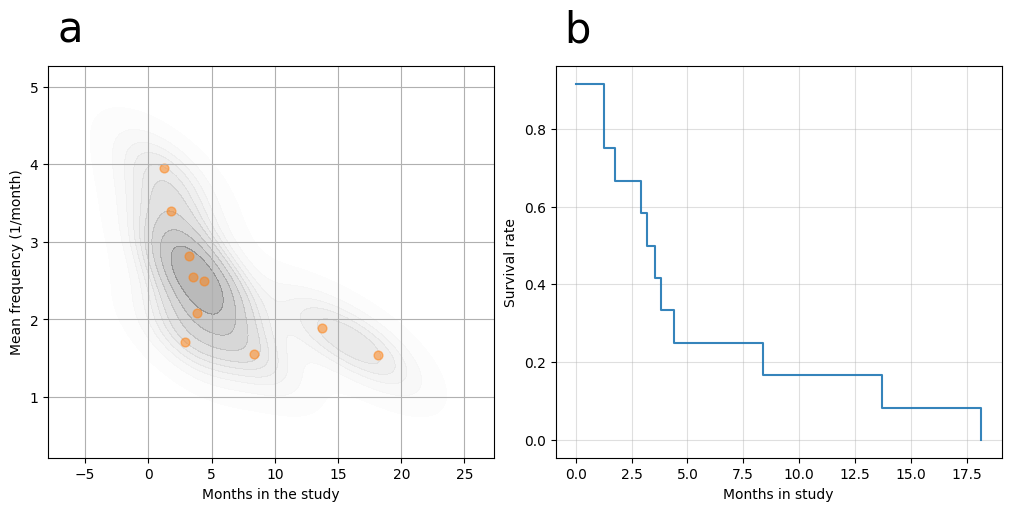

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(10, 5), layout='constrained')

# filter out the zeros
non_zero = df_dates['elapsed_months'] > 0
x = df_dates['elapsed_months'][non_zero]
y = df_dates['session_frequency_months'][non_zero]

####################################################
# Panel A
ax = axs[0]
sns.kdeplot(x=x, y=y, cmap="Greys", shade=True, bw_adjust=.8, alpha=.3, ax=ax)
ax.scatter(x,
           y, 
           color = sns.color_palette()[1],
           s = 40, 
           alpha=0.5,
           label = 'Patients')

# ax.set_xlim([-6,100])
# ax.set_ylim([0.25,1.25])
# ax.set_xticks(np.arange(0, 100, 24))
# ax.set_yticks(np.linspace(0.25, 1.25, 5, endpoint=True))
ax.set_xlabel('Months in the study')
ax.set_ylabel('Mean frequency (1/month)')
ax.grid()

####################################################
# Panel B
ax = axs[1]
df_cum = df_dates.copy()
df_cum = df_cum.groupby('user_id').first()
df_cum = df_cum.sort_values(by='elapsed_months')
df_cum['proportion'] = 1 - ((df_cum['elapsed_months'].rank(method='average') -1) / (len(df_cum)-1))

# Plot the reversed cumulative proportion
sns.lineplot(x=df_cum['elapsed_months'], 
             y=df_cum['proportion'], 
             color=sns.color_palette()[0],
             drawstyle='steps-post',
             alpha=0.9,
             ax=ax)

ax.set_xlabel('Months in study')
ax.set_ylabel('Survival rate')
ax.grid(True, alpha=0.4)

# ax.set_xlim([-6,100])
# ax.set_xticks(np.arange(0, 100, 24))
# ax.set_ylim(0, 1)
# ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
# ax.set_yticklabels([0, 25, 50, 75, 100])
# ax.avline

for ax, letter in zip(axs, 'ab'):
    ax.text(0.02, 1.09, letter, fontsize=30, va='center', ha='left', transform=ax.transAxes)

plt.show()

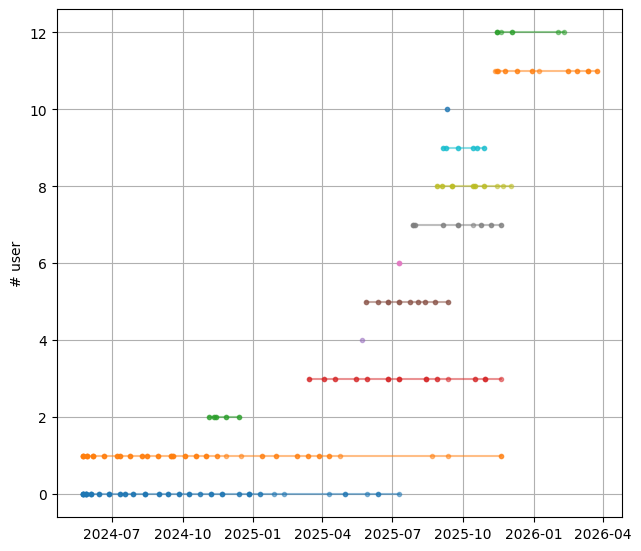

In [13]:
fig, axs = plt.subplots(1,1,figsize=(7*.9,6*.9),layout='constrained')
ax = axs
# users_min_dates = df_acc.groupby('user_id').date.min().to_frame().reset_index().sort_values('date').reset_index(drop=True)
users_min_dates = (
    df_zx.groupby('user_id').date.min()
    .to_frame()
    .reset_index()
    .sort_values('date')
    .reset_index(drop=True)
)
for index, row in users_min_dates.iterrows():
    # user_id = row['user_id']
    # df_temp = df_zx.query('user_id==@user_id').copy()
    # df_temp['date'] = pd.to_datetime(df_temp.date)
    # ax.plot(df_temp.date, np.ones(df_temp.shape[0])*index,'.-', alpha=0.5)
    user_id = row['user_id']
    df_temp = df_zx.query('user_id==@user_id')
    ax.plot(df_temp.date, np.ones(len(df_temp))*index, '.-', alpha=0.5)
ax.set_ylabel('# user')
ax.grid(True)